# **Randomly connected E/I SNN**

Of the form in O'Rawe et al. 2023, i.e. LIF neurons with conductance-based inputs from other neurons, but a current-based opsin input.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import brian2 as b2
from brian2 import ms, mV, nS, nA, pA, pF, second

In [24]:
# plot style
plt.rcParams.update({'font.size': 14})
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### **Model parameters**

In [ ]:
# Random seed for reproducibility
seed = 20250319
rng  = np.random.default_rng(seed)
b2.seed(seed)

# Connection parameters
N_exc = 8000
N_inh = 2000
p_conn = 0.02

# Membrane parameters
C_m = 500 * pF # 900 * pF # tau = C_m/g_L = 900 pF / 10 nS = 90 ms
g_L = 25 * nS # 10 * nS
E_L = -60 * mV
V_reset = -60 * mV
V_thresh = -45 * mV
tau_r = 5 * ms
I_bg_exc = 260 * pA
I_bg_inh = 140 * pA

# Synapse parameters
E_exc = 0 * mV
E_inh = - 80 * mV
tau_exc = 5 * ms
tau_inh = 5 * ms
w_ee_mean = 0.4 * nS
w_ee_var = 0.4 * nS
w_ei_mean = 0.8 * nS
w_ei_var = 0.8 * nS
w_ii_mean = 4.0 * nS
w_ii_var = 4.0 * nS
w_ie_mean = 5.0 * nS
w_ie_var = 5.0 * nS
I_bg_exc = 260 * pA
I_bg_inh = 140 * pA
delay_mean = 0 * ms
delay_var = 0 * ms

# Opsin parameters
k_exp_mean = 1 # proportion of full expression
k_exp_var = 0
I_max = 1200 * pA # maximum photocurrent at full expression

### **Define model**

In [84]:
# Re-start scope to clear any previous Brian objects
b2.start_scope()

# Define equations (and declare per-neuron variables and their units)
eq_str = """
idx = i                                                                                             : 1
dV/dt = (g_L * (E_L - V) + g_exc * (E_exc - V) + g_inh * (E_inh - V) + I_bg + k_exp * I_opto) / C_m : volt (unless refractory) # membrane potential
dg_exc/dt = -g_exc / tau_exc                                                                        : siemens                  # excitatory conductance
dg_inh/dt = -g_inh / tau_inh                                                                        : siemens                  # inhibitory conductance
I_bg                                                                                                : amp
I_opto                                                                                              : amp
k_exp                                                                                               : 1
"""
lif_eqs = b2.Equations(eq_str)

# Define network
neurons = b2.NeuronGroup(N=N_exc + N_inh,
                         model=lif_eqs,
                         threshold="V > V_thresh",
                         reset=f"V = V_reset",
                         refractory=tau_r,
                         method="euler",
                         name="neurons")

# initialise variables
neurons.V = E_L
neurons.g_exc = 0 * nS
neurons.g_inh = 0 * nS
neurons.I_opto = 0 * pA
neurons.k_exp = rng.normal(k_exp_mean, k_exp_var, size=neurons.N)
neurons.k_exp = np.clip(neurons.k_exp, a_min=0, a_max=1)  # clip to [0, 1]

# create variables for excitatory and inhibitory subgroups
neurons_exc = neurons[:N_exc]
neurons_inh = neurons[N_exc:]

# set background current per subgroup
neurons_exc.I_bg = I_bg_exc
neurons_inh.I_bg = I_bg_inh

# exc to exc
syn_ee = b2.Synapses(source=neurons_exc,
                     target=neurons_exc, 
                     model = "w_ee : siemens",
                     on_pre="g_exc += w_ee", # at pre-synaptic spike, increment post-synaptic g_exc by synaptic weight
                     method="euler",
                     name="syn_ee")

syn_ee.connect(p=p_conn)

ee_delay_vals = rng.normal(delay_mean/ms, delay_var/ms, size=syn_ee.N)
ee_delay_vals = np.clip(ee_delay_vals, a_min=0, a_max=None)  # clip to non-negative delays
w_ee_vals = rng.normal(w_ee_mean/nS, w_ee_var/nS, size=syn_ee.N)
w_ee_vals = np.clip(w_ee_vals, a_min=0, a_max=None)  # rectify to avoid negative weights

syn_ee.w_ee = w_ee_vals * nS
syn_ee.delay = ee_delay_vals * ms

# exc to inh
syn_ei = b2.Synapses(source=neurons_exc,
                     target=neurons_inh, 
                     model = "w_ei : siemens",
                     on_pre="g_exc += w_ei", # at pre-synaptic spike, increment post-synaptic g_exc by synaptic weight
                     method="euler",
                     name="syn_ei")

syn_ei.connect(p=p_conn)

ei_delay_vals = rng.normal(delay_mean/ms, delay_var/ms, size=syn_ei.N)
ei_delay_vals = np.clip(ei_delay_vals, a_min=0, a_max=None)  # clip to non-negative delays
w_ei_vals = rng.normal(w_ei_mean/nS, w_ei_var/nS, size=syn_ei.N)
w_ei_vals = np.clip(w_ei_vals, a_min=0, a_max=None)  # rectify to avoid negative weights

syn_ei.w_ei = w_ei_vals * nS
syn_ei.delay = ei_delay_vals * ms

# inh to inh
syn_ii = b2.Synapses(source=neurons_inh,
                     target=neurons_inh, 
                     model = "w_ii : siemens",
                     on_pre="g_inh += w_ii",
                     method="euler",
                     name="syn_ii")

syn_ii.connect(p=p_conn)

ii_delay_vals = rng.normal(delay_mean/ms, delay_var/ms, size=syn_ii.N)
ii_delay_vals = np.clip(ii_delay_vals, a_min=0, a_max=None)
w_ii_vals = rng.normal(w_ii_mean/nS, w_ii_var/nS, size=syn_ii.N)
w_ii_vals = np.clip(w_ii_vals, a_min=0, a_max=None)

syn_ii.w_ii = w_ii_vals * nS
syn_ii.delay = ii_delay_vals * ms

# inh to exc
syn_ie = b2.Synapses(source=neurons_inh,
                     target=neurons_exc, 
                     model = "w_ie : siemens",
                     on_pre="g_inh += w_ie", 
                     method="euler",
                     name="syn_ie")

syn_ie.connect(p=p_conn)

ie_delay_vals = rng.normal(delay_mean/ms, delay_var/ms, size=syn_ie.N)
ie_delay_vals = np.clip(ie_delay_vals, a_min=0, a_max=None)
w_ie_vals = rng.normal(w_ie_mean/nS, w_ie_var/nS, size=syn_ie.N)
w_ie_vals = np.clip(w_ie_vals, a_min=0, a_max=None)

syn_ie.w_ie = w_ie_vals * nS
syn_ie.delay = ie_delay_vals * ms


### **Define simulation parameters**

In [85]:
# Simulation parameters
dt = 0.1 * ms

t_stim = 600 * ms
t_pre = 0 * ms
t_post = 400 * ms
t_total = t_pre + t_stim + t_post

n_timesteps_total = int(t_total / dt)
n_timesteps_stim = int(t_stim / dt)
n_timesteps_pre = int(t_pre / dt)
n_timesteps_post = int(t_post / dt)

n_trials = 1

# Stimulation waveform
I_stim = I_max * np.ones(n_timesteps_stim) # constant current during stimulation period (square wave)
stim_array = np.zeros(n_timesteps_total) * pA # initialize array for full simulation duration
stim_array[n_timesteps_pre:n_timesteps_pre + n_timesteps_stim] = I_stim

# Num timesteps to stimulate
n_timesteps_sim = int(t_total / dt)

### **Run simulation**

In [86]:
# Set simulation timestep
b2.defaultclock.dt = dt

In [87]:
# Create monitor objects
spike_mon = b2.SpikeMonitor(neurons, name="spike_mon")
state_mon = b2.StateMonitor(neurons, ["V", "g_exc", "g_inh"], record=True, name="state_mon", dt=1*ms)

In [88]:
# Run simulation
t0 = b2.defaultclock.t
for trial in range(n_trials):
    print(f"Running trial {trial + 1}/{n_trials}...")
    
    # Update optogenetic current for all neurons at each timestep
    for t in range(n_timesteps_sim):

        # set opsin current for excitatory neurons based on stimulation waveform
        neurons_exc.I_opto = stim_array[t]
        
        # run the simulation for one timestep
        b2.run(dt, report='text')

t_total_sim = b2.defaultclock.t - t0
print(f"Total simulation time: {t_total_sim:.2f}")

Running trial 1/1...
Starting simulation at t=0. s for a duration of 100. us
100. us (100%) simulated in < 1s
Starting simulation at t=100. us for a duration of 100. us
100. us (100%) simulated in < 1s
Starting simulation at t=200. us for a duration of 100. us
100. us (100%) simulated in < 1s
Starting simulation at t=300. us for a duration of 100. us
100. us (99%) simulated in < 1s, estimated < 1s remaining.
Starting simulation at t=0.4 ms for a duration of 100. us
100. us (99%) simulated in < 1s, estimated < 1s remaining.
Starting simulation at t=0.5 ms for a duration of 100. us
100. us (100%) simulated in < 1s
Starting simulation at t=0.6 ms for a duration of 100. us
100. us (100%) simulated in < 1s
Starting simulation at t=0.7 ms for a duration of 100. us
100. us (100%) simulated in < 1s
Starting simulation at t=0.8 ms for a duration of 100. us
100. us (100%) simulated in < 1s
Starting simulation at t=0.9 ms for a duration of 100. us
100. us (100%) simulated in < 1s
Starting simulat

### **Analyse results**

In [91]:
sigma = 0.001 # standard deviation for Gaussian kernel (in bins)

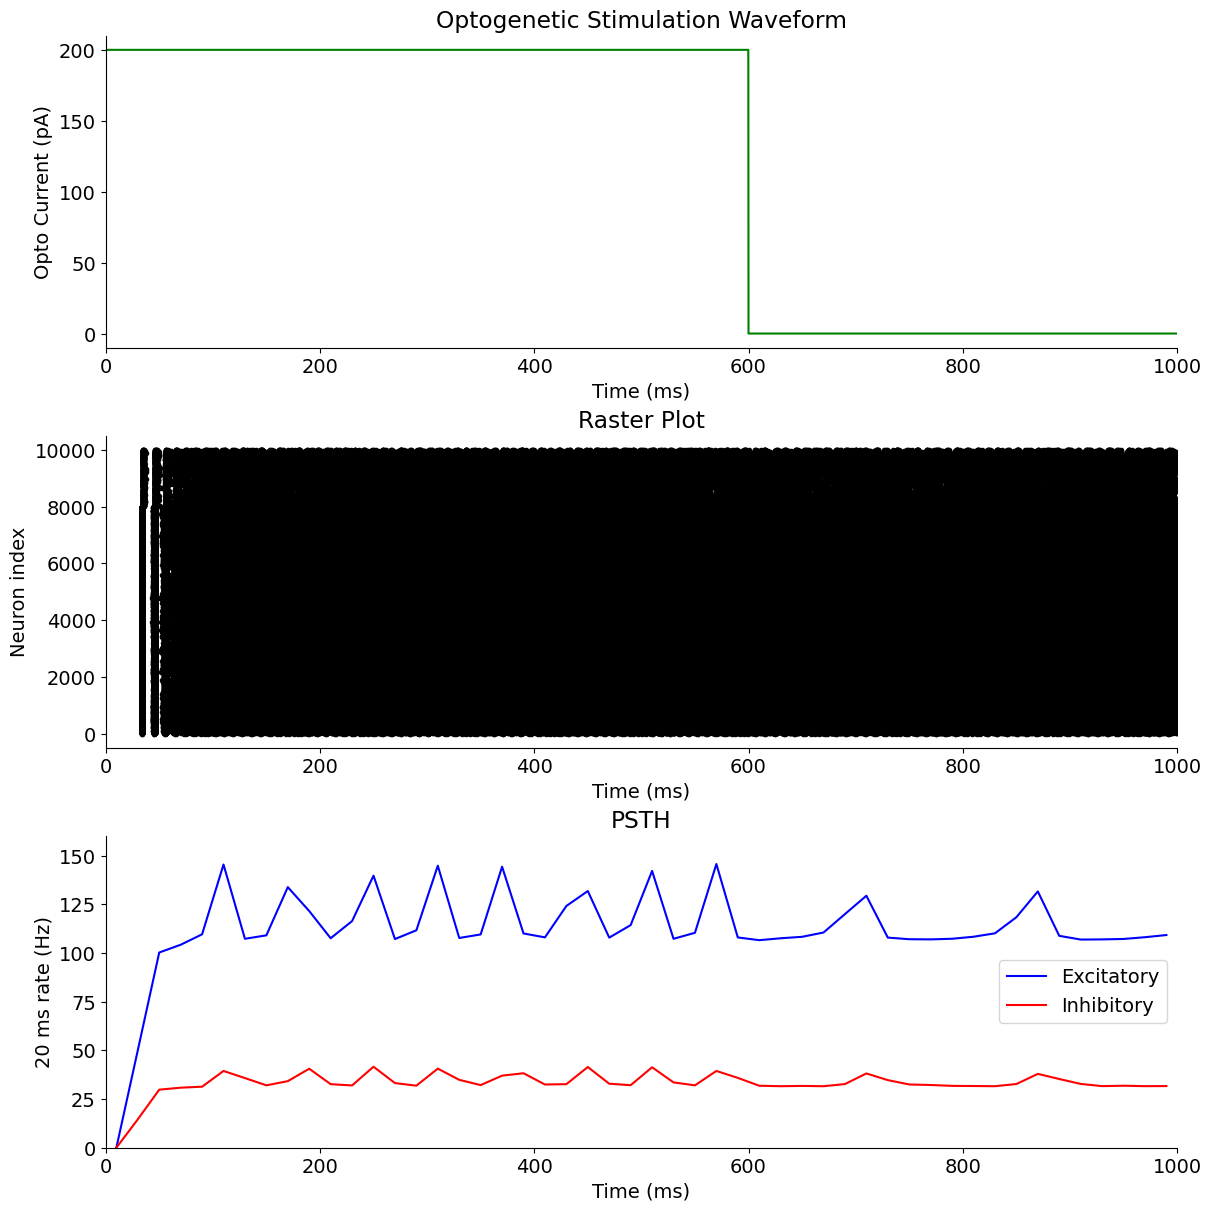

In [93]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 12))

# stim waveform
ax[0].set_title("Optogenetic Stimulation Waveform")
ax[0].plot(np.arange(n_timesteps_total) * dt/ms, stim_array/pA, "-g")
ax[0].set_xlabel("Time (ms)")
ax[0].set_ylabel("Opto Current (pA)")
ax[0].set_xlim(0, t_total/ms)

# raster plot
ax[1].set_title("Raster Plot")
ax[1].plot(spike_mon.t/ms, spike_mon.i, ".k")
ax[1].set_xlabel("Time (ms)")
ax[1].set_ylabel("Neuron index")
ax[1].set_xlim(0, t_total/ms)

# PSTH
bin_size = 20 * ms
bins = np.arange(0, t_total + bin_size, bin_size)
bin_centers = (bins[:-1] + bins[1:]) / 2
spike_counts, _ = np.histogram(spike_mon.t, bins=bins)
exc_spike_counts, _ = np.histogram(spike_mon.t[spike_mon.i < N_exc], bins=bins)
inh_spike_counts, _ = np.histogram(spike_mon.t[spike_mon.i >= N_exc], bins=bins)

# histogram PSTHs
# ax[2].bar(bin_centers * 1000, spike_counts, width=bin_size/ms, color="gray", edgecolor="black")
# ax[2].bar(bin_centers * 1000, spike_counts, width=bin_size/ms, color="gray", edgecolor="black")
# ax[2].bar(bin_centers * 1000, exc_spike_counts, width=bin_size/ms, color="blue", edgecolor="black")
# ax[2].bar(bin_centers * 1000, inh_spike_counts, width=bin_size/ms, color="red", edgecolor="black")

# smoothed PSTH
smoothed_exc = gaussian_filter1d(exc_spike_counts, sigma)
smoothed_inh = gaussian_filter1d(inh_spike_counts, sigma)

# normalise to get in units of firing rate (spikes/s)
smoothed_exc = smoothed_exc / bin_size / N_exc
smoothed_inh = smoothed_inh / bin_size / N_inh

ax[2].set_title("PSTH")
ax[2].plot(bin_centers * 1000, smoothed_exc, "-b", label="Excitatory")
ax[2].plot(bin_centers * 1000, smoothed_inh, "-r", label="Inhibitory")
ax[2].legend()

ax[2].set_xlabel("Time (ms)")
ax[2].set_ylabel(f"{bin_size/ms:.0f} ms rate (Hz)")
ax[2].set_xlim(0, t_total/ms)   
ax[2].set_ylim(0, max(smoothed_exc.max(), smoothed_inh.max()) * 1.1)
fig.set_constrained_layout(True)